# iMPORTING DEPENDENCIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import joblib
import seaborn as sns

# Set Path Data Collection

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
import pandas as pd
import os
x=os.path.join(path,"creditcard.csv")
df=pd.read_csv(x)

# Data Selection

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


# Getting Some information about the dataset

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.duplicated().sum()


np.int64(1081)

In [ ]:
df.drop_duplicates(inplace=True)


Data visulazation

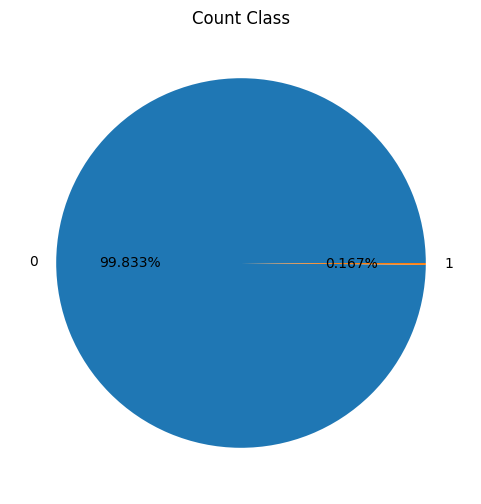

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(df['Class'].value_counts(),labels=df['Class'].value_counts().index,autopct='%.3f%%')
plt.title("Count Class")
plt.show()


# Use Of RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
rob_scaler = RobustScaler()

In [ ]:
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

In [ ]:
df.drop(['Time','Amount'], axis=1, inplace=True, errors='ignore')
scaled_features = df[['scaled_amount', 'scaled_time']]
other_features = df.drop(['scaled_amount', 'scaled_time'], axis=1)
df = pd.concat([scaled_features, other_features], axis=1)

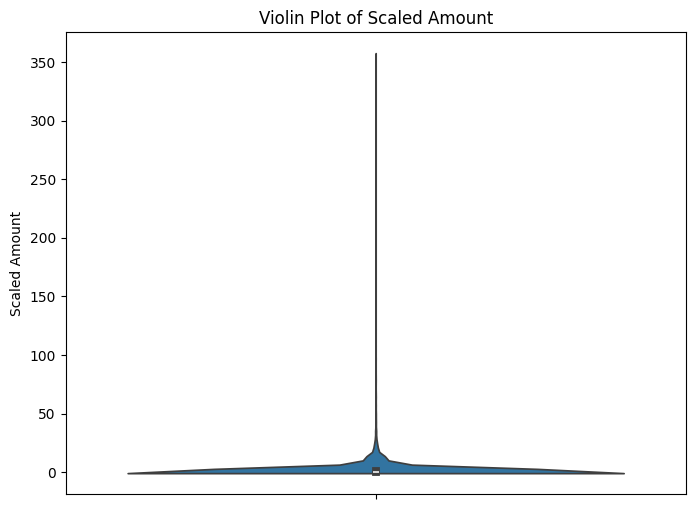

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(y=df['scaled_amount'])
plt.title('Violin Plot of Scaled Amount')
plt.ylabel('Scaled Amount')
plt.show()

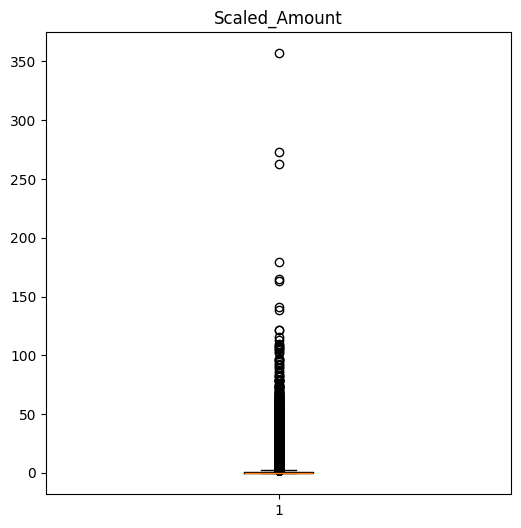

In [ ]:
plt.figure(figsize=(6,6))
plt.boxplot(df["scaled_amount"])
plt.title("Scaled_Amount")
plt.show()

This violin plot shows the distribution of the `scaled_amount` column. The thicker sections represent a higher probability density (more data points), while the thinner sections represent lower density. The inner box plot shows the quartiles (25th, 50th, and 75th percentiles) and potential outliers.

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
rob_scaler = RobustScaler()

In [ ]:
df.drop(['Time','Amount'], axis=1, inplace=True, errors='ignore')
scaled_features = df[['scaled_amount', 'scaled_time']]
other_features = df.drop(['scaled_amount', 'scaled_time'], axis=1)
df = pd.concat([scaled_features, other_features], axis=1)

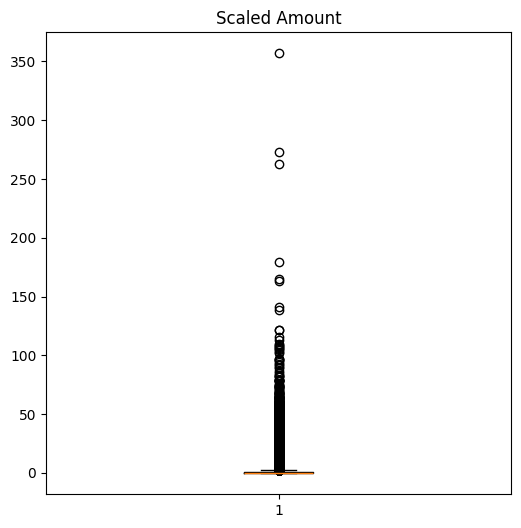

In [ ]:
plt.figure(figsize=(6,6))
plt.boxplot(df['scaled_amount'])
plt.title("Scaled Amount")
plt.show()

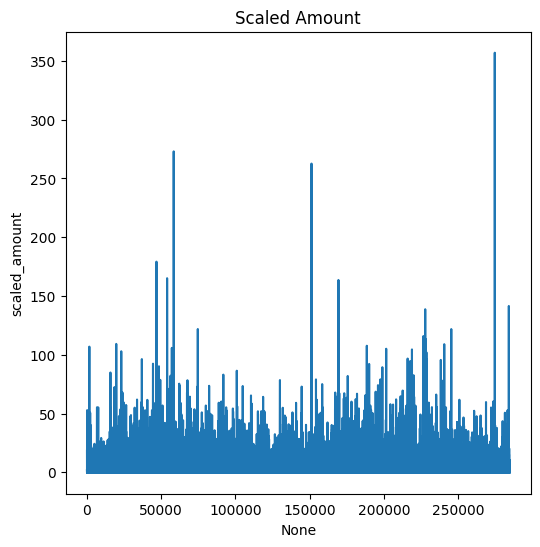

In [ ]:
plt.figure(figsize=(6,6))
sns.lineplot(x=df.index,y=df['scaled_amount'])
plt.title("Scaled Amount")
plt.show()

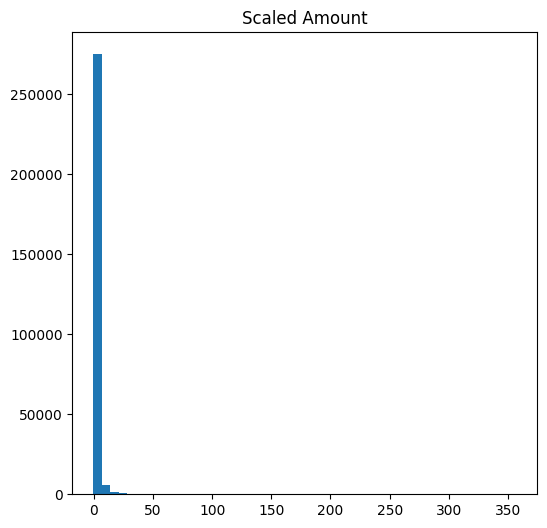

In [ ]:
plt.figure(figsize=(6,6))
plt.hist(df['scaled_amount'],bins=50)
plt.title("Scaled Amount")
plt.show()

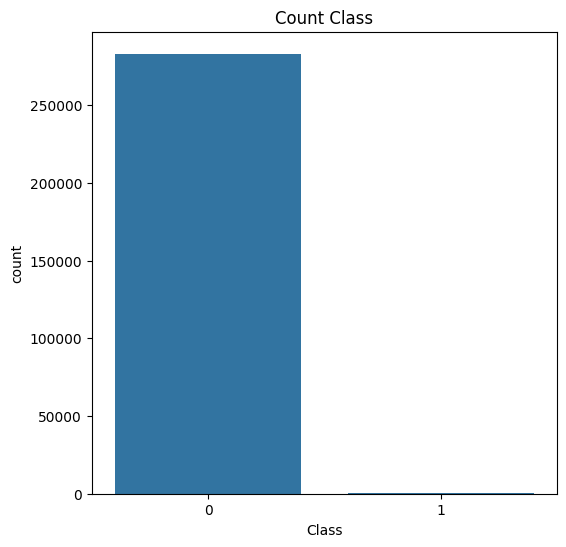

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x=df['Class'])
plt.title("Count Class")
plt.show()

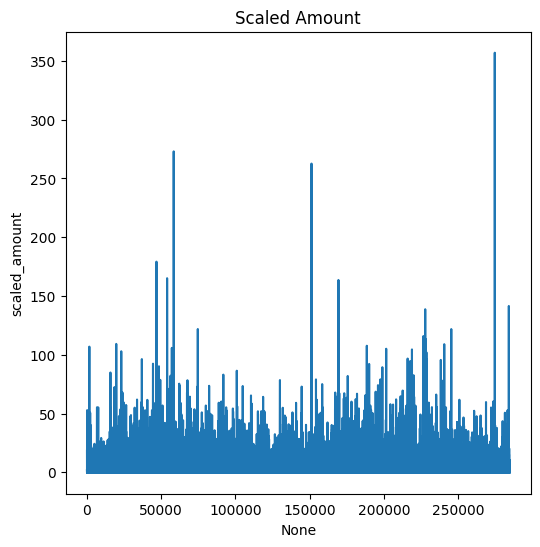

In [ ]:
plt.figure(figsize=(6,6))
sns.lineplot(x=df.index,y=df['scaled_amount'])
plt.title("Scaled Amount")
plt.show()

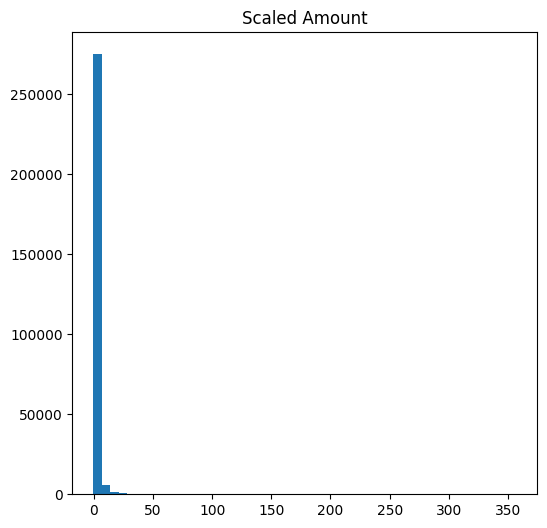

In [ ]:
plt.figure(figsize=(6,6))
plt.hist(df['scaled_amount'],bins=50)
plt.title("Scaled Amount")
plt.show()

#This Dataset is highly unblanced
0 --> Normal Transaction
1 --> fraudulent transaction
The first line of code creates a new dataframe called "legit" by selecting only the rows from the original "credit_card_data" dataframe where the "Class" label is equal to 0. In other words, it filters out all transactions labeled as fraudulent (Class == 1) and keeps only the legitimate transactions (Class == 0).

The second line of code creates a new dataframe called "fraud" by selecting only the rows from the original "credit_card_data" dataframe where the "Class" label is equal to 1. This filters out all legitimate transactions and keeps only the fraudulent transactions.

By separating the data into two dataframes, it becomes easier to analyze and compare the characteristics of legitimate and fraudulent transactions separately. This can be useful for identifying patterns or features that are more common in fraudulent transactions, which can then be used to develop models for fraud detection.



In [ ]:
# ADVANCED SCALING (RobustScaler) ---
# Amount aur Time column ki range alag hai, isliye Scale karna zaroori hai
from sklearn.preprocessing import RobustScaler

In [ ]:
rob_scaler = RobustScaler()

In [ ]:
df.drop(['Time','Amount'], axis=1, inplace=True, errors='ignore')
scaled_features = df[['scaled_amount', 'scaled_time']]
other_features = df.drop(['scaled_amount', 'scaled_time'], axis=1)
df = pd.concat([scaled_features, other_features], axis=1)

# SPLITTING Data into x And Y & Use SMOTE

In [ ]:
# SPLITTING & SMOTE (Correct Approach

X = df.drop('Class', axis=1)
Y = df['Class']

In [ ]:
# Pehle Split (Stratified) - Original Imbalanced Data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
# Phir SMOTE (Sirf Training Data Par apply hoga)
# Note: Terminal mein 'pip install imbalanced-learn' zaroor run karein
from imblearn.over_sampling import SMOTE

In [ ]:
print("SMOTE se pehle fraud cases (Train):", sum(y_train==1))

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print("SMOTE ke baad fraud cases (Train):", sum(y_train_resampled==1))

SMOTE se pehle fraud cases (Train): 378
SMOTE ke baad fraud cases (Train): 226602


# LOGISTIC REGRESSION


## MODEL TRAINING

In [ ]:
# MODEL TRAINING

# LOGISTIC REGRESSION
log_reg = LogisticRegression(max_iter=1000) # Iterations barha di taake error na aaye
param_grid = [
    {'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear']},
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs']}
]

In [ ]:
# Advanced Metric: 'f1' instead of 'accuracy'
grid_search = GridSearchCV(log_reg, param_grid, cv=3, scoring='f1')

In [ ]:
# Fit on RESAMPLED data (Balanced)
grid_search.fit(x_train_resampled, y_train_resampled)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000),
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear']},
                         {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                          'solver': ['lbfgs']}],
             scoring='f1')

In [ ]:
print("Best param LogReg:", grid_search.best_params_)
print("Best F1 Score LogReg:", grid_search.best_score_)

Best param LogReg: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 Score LogReg: 0.9470610049684828


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test, grid_search.predict(x_test))

array([[55186,  1465],
       [   12,    83]])

In [ ]:
# Predict on TEST data (Original Imbalanced)
pred = grid_search.predict(x_test)
print("\nLogistic Regression Report:")
print(classification_report(y_test, pred))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [ ]:
# Save Logistic Model
joblib.dump(grid_search.best_estimator_, 'logistic_model_advanced.pkl')

['logistic_model_advanced.pkl']

# RandomForest

In [ ]:
# RANDOM FOREST
rand = RandomForestClassifier()

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'criterion': ['gini']
}

In [ ]:
param_grid_rf

{'n_estimators': [50, 100], 'max_depth': [10, 20], 'criterion': ['gini']}

In [ ]:
grid_search_rf = GridSearchCV(rand, param_grid_rf, cv=3, scoring='f1')

In [ ]:
grid_search_rf

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini'], 'max_depth': [10, 20],
                         'n_estimators': [50, 100]},
             scoring='f1')

In [ ]:
# Fit on RESAMPLED data
grid_search_rf.fit(x_train_resampled, y_train_resampled)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini'], 'max_depth': [10, 20],
                         'n_estimators': [50, 100]},
             scoring='f1')

In [ ]:
print("\nBest param RF:", grid_search_rf.best_params_)
pred_rf = grid_search_rf.predict(x_test)



Best param RF: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 50}


In [ ]:
pred_rf

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
print("Random Forest Report:")
print(classification_report(y_test, pred_rf))

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.78      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.89      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
# Save RF Model
joblib.dump(grid_search_rf.best_estimator_, 'rf_model_advanced.pkl')

['rf_model_advanced.pkl']

# confusion_matrix

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
# Confusion Matrix for Random Forest (Ya Best Model)
cm = confusion_matrix(y_test, pred_rf)

In [ ]:
cm

array([[56640,    11],
       [   21,    74]])

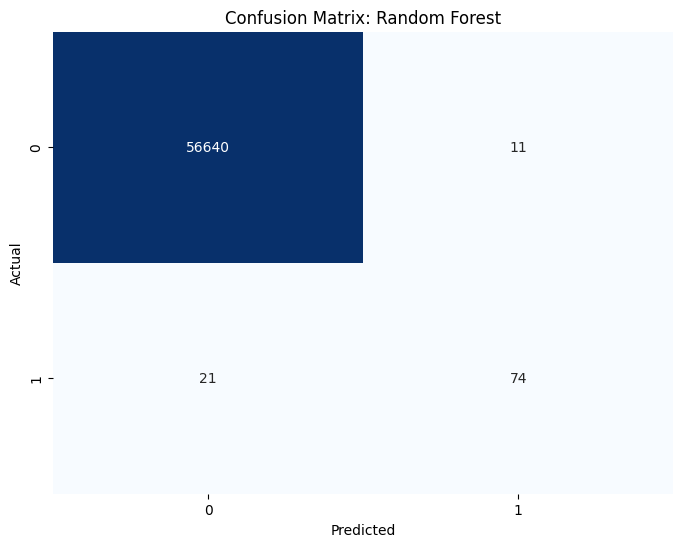

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.show()

# precision_recall_curve

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

In [ ]:
# Model se probabilities lein (0 ya 1 nahi, balkay % chance)
y_pred_prob = grid_search_rf.predict_proba(x_test)[:, 1]

In [ ]:
y_pred_prob

array([0.        , 0.        , 0.01944272, ..., 0.00015444, 0.        ,
       0.        ])

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
y_pred_prob = grid_search_rf.predict_proba(x_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
auc_score = auc(recall, precision)

In [ ]:
auc_score

np.float64(0.8137644799154824)

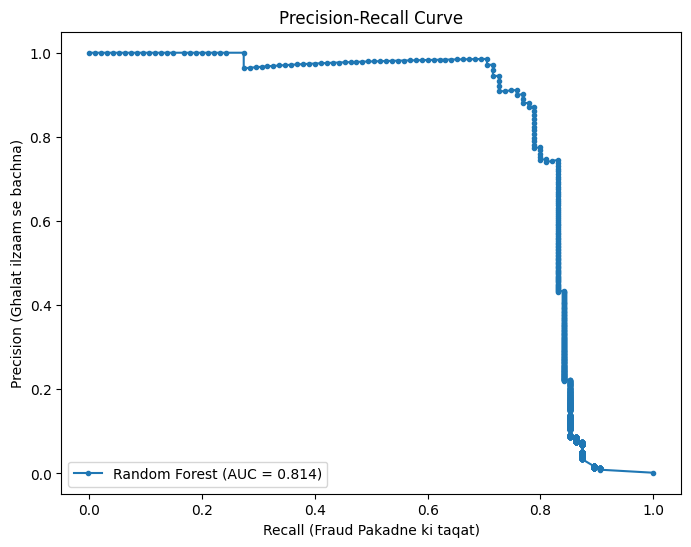

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'Random Forest (AUC = {auc_score:.3f})')
plt.xlabel('Recall (Fraud Pakadne ki taqat)')
plt.ylabel('Precision (Ghalat ilzaam se bachna)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [ ]:
# Threshold ko 0.5 se 0.3 kar diya
threshold = 0.3
y_pred_adjusted = (y_pred_prob >= threshold).astype(int)

print("Adjusted Report (Threshold 0.3):")
print(classification_report(y_test, y_pred_adjusted))

Adjusted Report (Threshold 0.3):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.83      0.77        95

    accuracy                           1.00     56746
   macro avg       0.86      0.92      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


# Data visu;ization

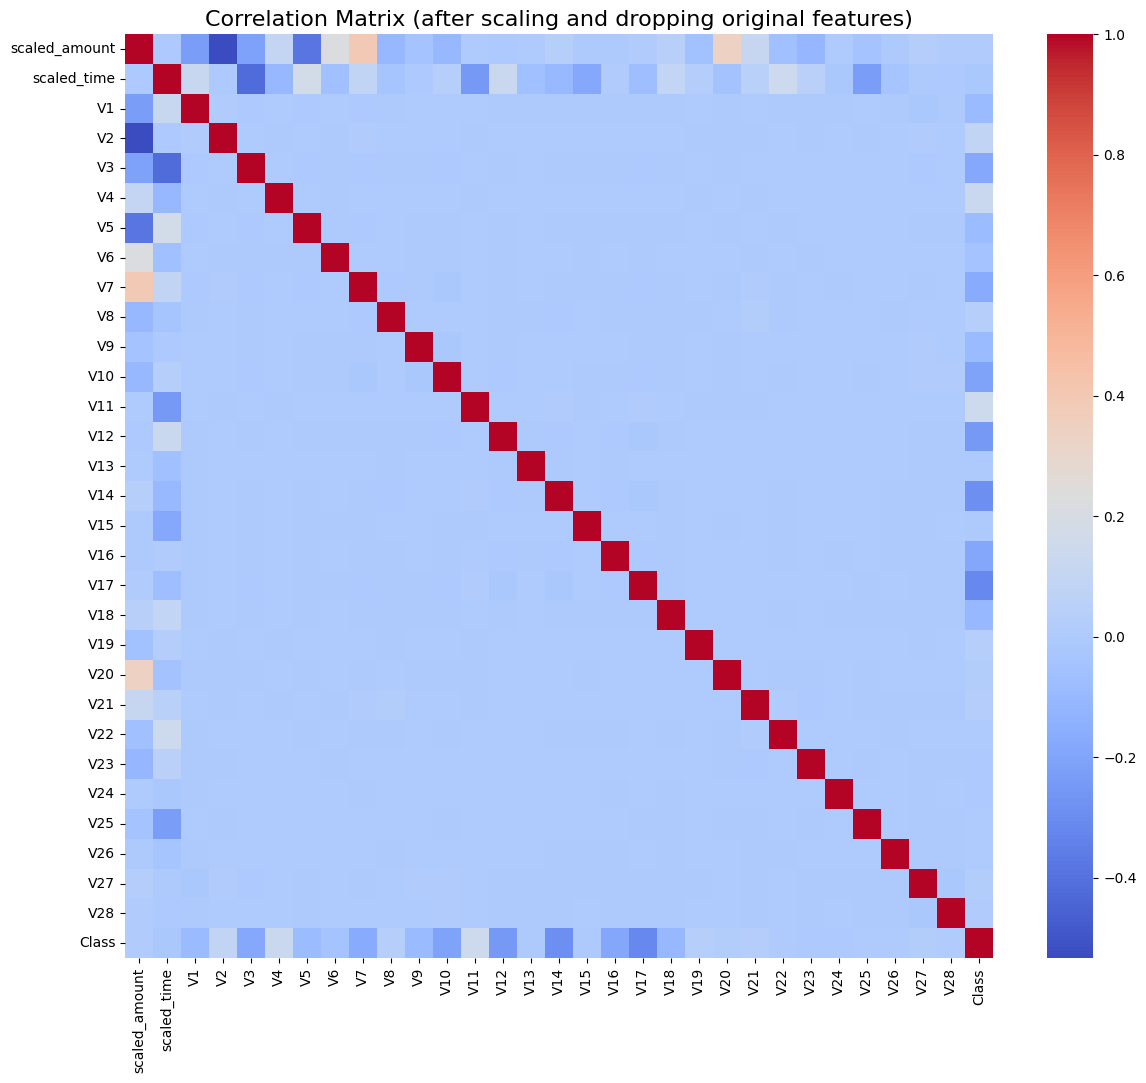

In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix (after scaling and dropping original features)', fontsize=16)
plt.show()

<Axes: xlabel='scaled_amount', ylabel='scaled_time'>

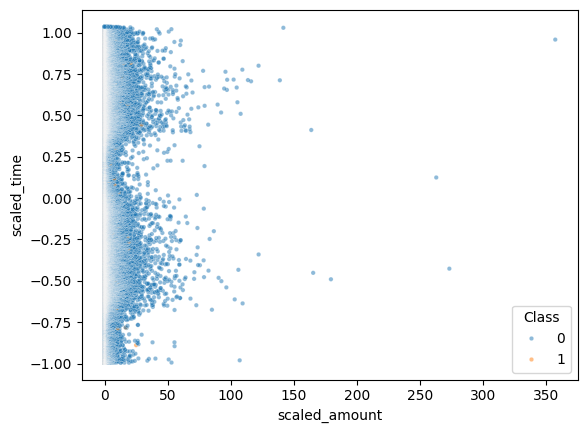

In [ ]:
sns.scatterplot(data=df, x='scaled_amount', y='scaled_time', hue='Class', alpha=0.5, s=10)

<Axes: xlabel='Class', ylabel='scaled_amount'>

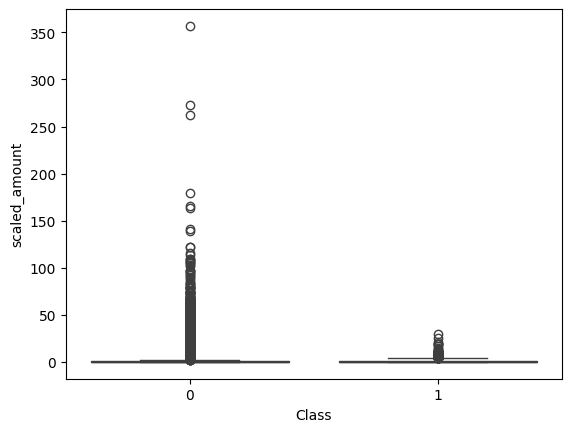

In [ ]:
sns.boxplot(data=df, x='Class', y='scaled_amount')

/tmp/ipython-input-2271766927.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([class_0_amount, class_1_amount], labels=['Class 0 (Normal)', 'Class 1 (Fraud)'], patch_artist=True)


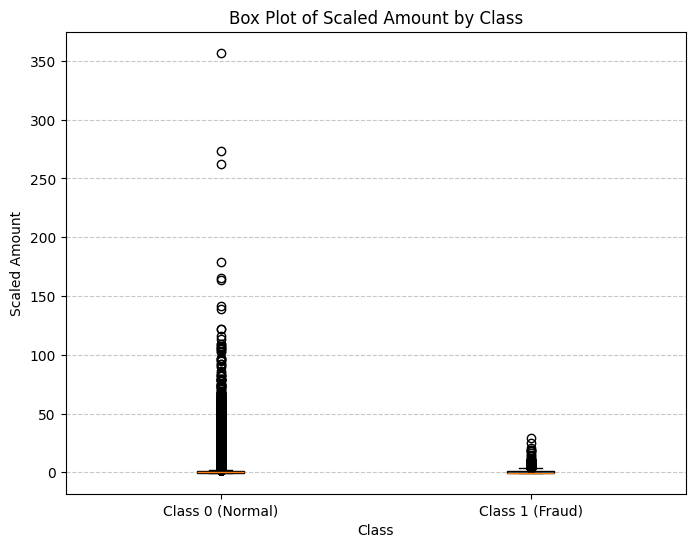

In [ ]:
# Extract scaled_amount for each class
class_0_amount = df[df['Class'] == 0]['scaled_amount']
class_1_amount = df[df['Class'] == 1]['scaled_amount']

# Create the boxplot using matplotlib.pyplot
plt.figure(figsize=(8, 6))
plt.boxplot([class_0_amount, class_1_amount], labels=['Class 0 (Normal)', 'Class 1 (Fraud)'], patch_artist=True)
plt.title('Box Plot of Scaled Amount by Class')
plt.ylabel('Scaled Amount')
plt.xlabel('Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

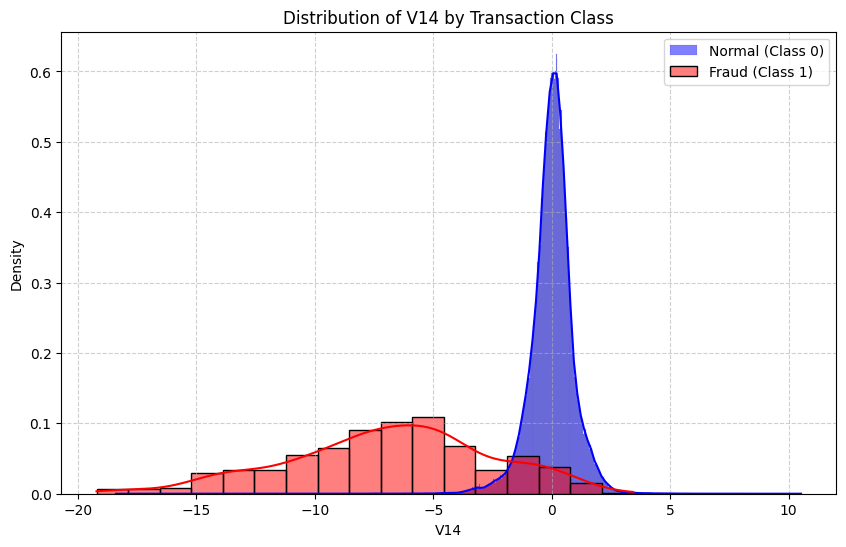

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create separate dataframes for normal and fraudulent transactions
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

# Choose a feature to visualize, for example, 'V14'
feature_to_plot = 'V14'

plt.figure(figsize=(10, 6))
sns.histplot(normal_transactions[feature_to_plot], color='blue', label='Normal (Class 0)', kde=True, stat='density', alpha=0.5)
sns.histplot(fraud_transactions[feature_to_plot], color='red', label='Fraud (Class 1)', kde=True, stat='density', alpha=0.5)

plt.title(f'Distribution of {feature_to_plot} by Transaction Class')
plt.xlabel(feature_to_plot)
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This plot helps us see if the distribution of a particular feature, like `V14`, is significantly different for fraudulent transactions compared to normal ones. A clear separation or distinct peaks for the two classes indicates that the feature is a good discriminator.

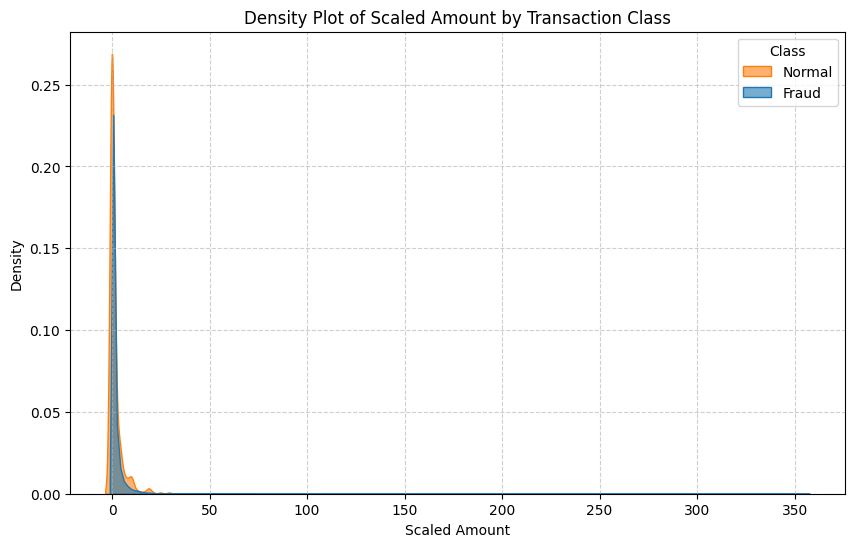

In [ ]:
# KDE plot for scaled_amount by Class
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='scaled_amount', hue='Class', fill=True, common_norm=False, alpha=0.6)
plt.title('Density Plot of Scaled Amount by Transaction Class')
plt.xlabel('Scaled Amount')
plt.ylabel('Density')
plt.legend(title='Class', labels=['Normal', 'Fraud'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Is cell ko Colab mein run karein model save karne ke liye
import joblib
joblib.dump(grid_search_rf.best_estimator_, 'rf_model_advanced.pkl')

['rf_model_advanced.pkl']

<Axes: xlabel='scaled_amount', ylabel='scaled_time'>

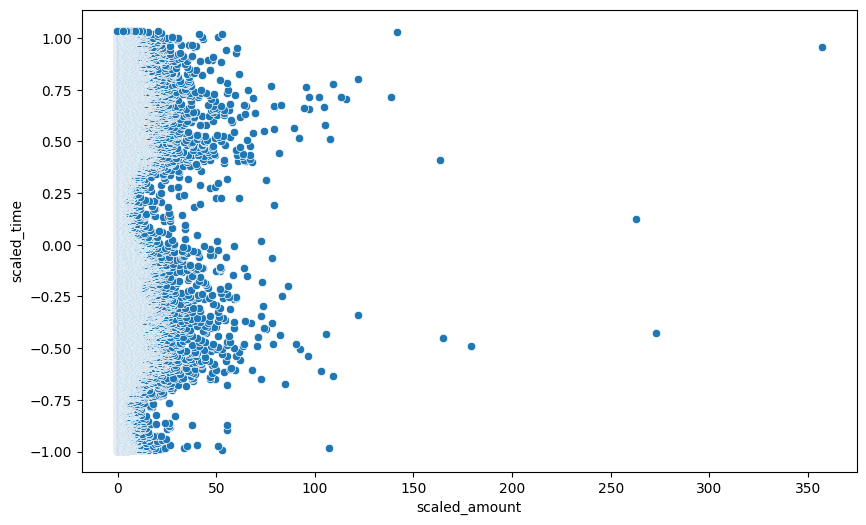

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='scaled_amount', y='scaled_time')

In [ ]:
import pandas as pd
import os

# Assuming 'path' is already defined from previous cells, if not, please run:
# import kagglehub
# path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Re-load the original DataFrame to ensure 'Time' and 'Amount' columns are present
x = os.path.join(path, "creditcard.csv")
df = pd.read_csv(x)

# Display head to confirm original columns are back
print("DataFrame after re-loading:")
display(df.head())

DataFrame after re-loading:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

# Apply RobustScaler to 'Amount' and 'Time'
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

print("DataFrame after scaling 'Amount' and 'Time':")
display(df.head())

DataFrame after scaling 'Amount' and 'Time':


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_amount,scaled_time
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1.783274,-0.994983
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.269825,-0.994983
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,4.983721,-0.994972
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1.418291,-0.994972
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.670579,-0.994960


In [ ]:
# Drop the original 'Time' and 'Amount' columns and reorder the DataFrame
df.drop(['Time','Amount'], axis=1, inplace=True, errors='ignore')

# Create separate dataframes for scaled and other features
scaled_features = df[['scaled_amount', 'scaled_time']]
other_features = df.drop(['scaled_amount', 'scaled_time'], axis=1)

# Concatenate them to have scaled features at the beginning
df = pd.concat([scaled_features, other_features], axis=1)

print("Final DataFrame with scaled features and original columns dropped:")
display(df.head())

Final DataFrame with scaled features and original columns dropped:


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0
